<a href="https://colab.research.google.com/github/Aryan123Yad/madeeasy/blob/main/carpriceprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


In [4]:
import pandas as pd
import zipfile
import io

# Assuming 'uploaded' is populated from the previous cell
# Check if the zip file was uploaded and extract its contents
if 'archive (5).zip' in uploaded:
    with zipfile.ZipFile(io.BytesIO(uploaded['archive (5).zip']), 'r') as z:
        z.extractall() # This will extract ford.csv to the current directory

df = pd.read_csv("ford.csv")

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
df = pd.read_csv("ford.csv")

In [6]:
print(df.shape)

(17966, 9)


In [7]:
print(df.columns)

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [9]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [10]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("ford.csv")

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


#EDA

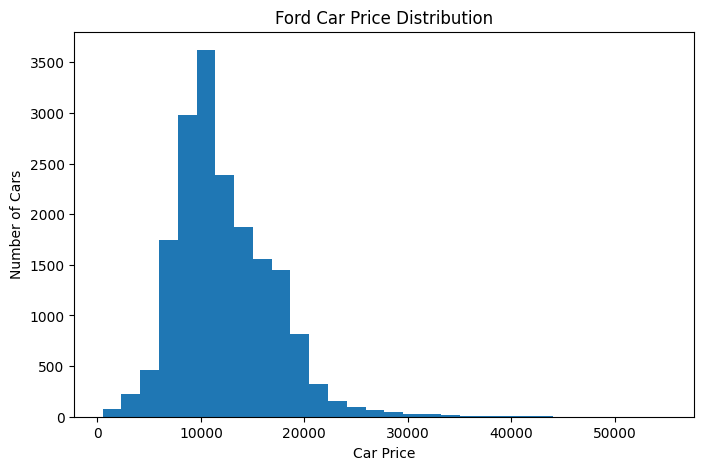

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.xlabel("Car Price")
plt.ylabel("Number of Cars")
plt.title("Ford Car Price Distribution")
plt.show()

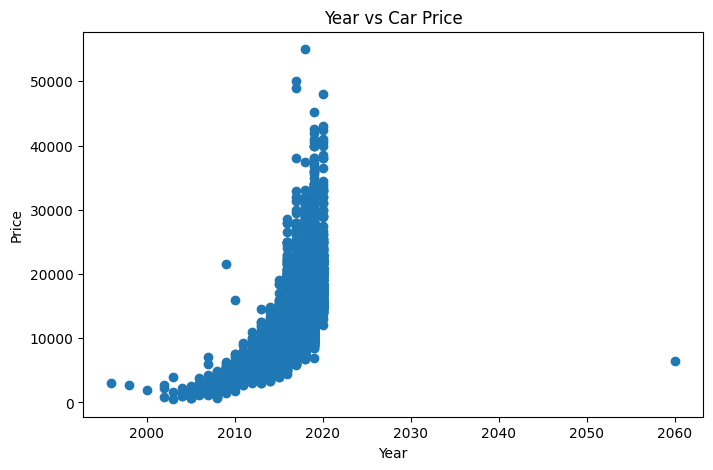

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(df["year"], df["price"])

plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Car Price")

plt.show()

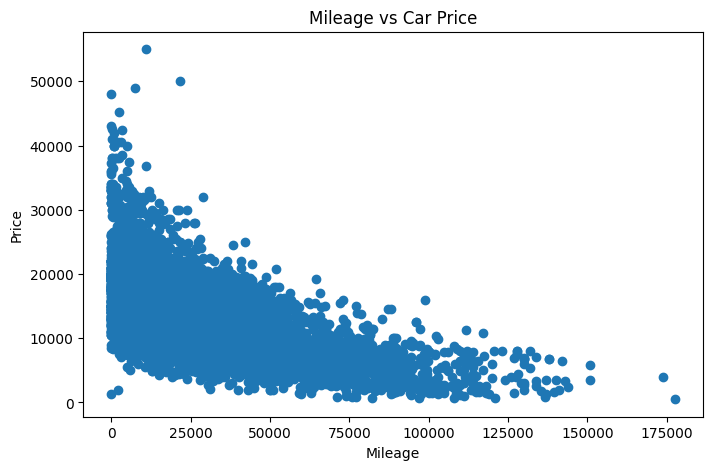

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df["mileage"], df["price"])

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Car Price")

plt.show()

In [15]:
X = df.drop("price", axis=1)

y = df["price"]

In [16]:
print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
     model  year transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019    Automatic     1482   Petrol  145  48.7         1.0

y:
0    12000
1    14000
2    13000
3    17500
4    16500
Name: price, dtype: int64


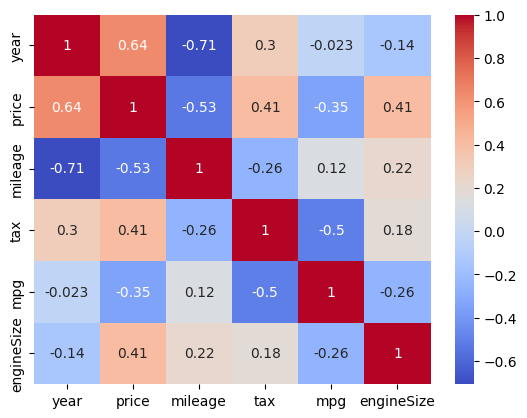

In [17]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

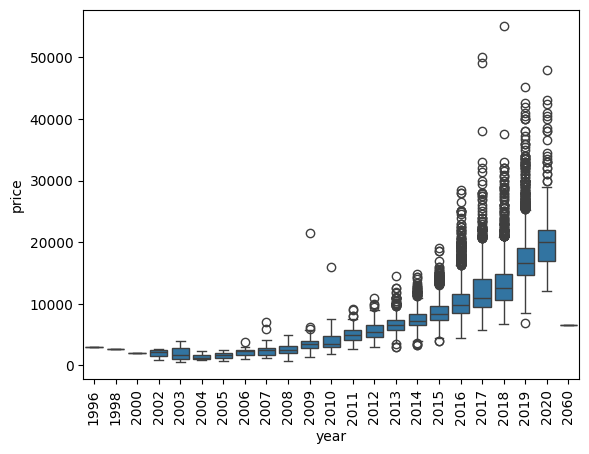

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="year", y="price")
plt.xticks(rotation=90)
plt.show()